# asymptotics — Lindstedt–Poincaré Method

Regular perturbation fails for nonlinear oscillators because **secular terms** like $t\sin t$ grow without bound. The Lindstedt–Poincaré method fixes this by introducing a **strained time coordinate**:

$$\tau = \omega(\varepsilon)\,t, \qquad \omega = \omega_0 + \varepsilon\omega_1 + \varepsilon^2\omega_2 + \cdots$$

At each order we choose $\omega_k$ to **eliminate secular terms**, yielding a **uniformly valid** expansion.

The API is identical to `expand_regular` — just call `expand_lindstedt` instead:

```python
from asymptotics import ODE

eq  = ODE("u'' + u + eps*u**3", dependent="u", small_param="eps", independent="t",
          conditions=["u(0) = 1", "u'(0) = 0"])
sol = eq.expand_lindstedt(order=2)
sol.show()
```

In [16]:
from asymptotics import ODE
%config InlineBackend.figure_format = 'svg'

---
## Example 1 — The Duffing oscillator

$$u'' + u + \varepsilon u^3 = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

The Duffing oscillator is the canonical test for Lindstedt. Regular perturbation gives a secular term $t\sin t$ at $\mathcal{O}(\varepsilon)$. Lindstedt eliminates it by finding:

$$\omega_1 = \frac{3}{8} \qquad \Longrightarrow \qquad \omega(\varepsilon) = 1 + \frac{3}{8}\varepsilon - \frac{21}{256}\varepsilon^2 + \cdots$$

The nonlinear spring **stiffens** — the frequency increases with amplitude.

In [27]:
eq = ODE(
    "u'' + u + eps*u**3",
    small_param = "eps",
    conditions  = ["u(0) = 1", "u'(0) = 0"])
sol = eq.expand_lindstedt(order=2)
sol.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (inferred from equation)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

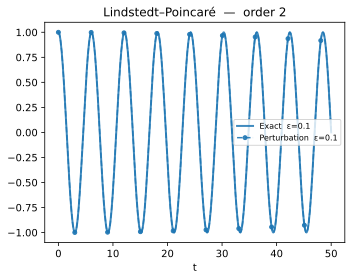

In [28]:
sol.compare_numeric(eps=0.1,plot_range=[0,50]);

---
## Example 2 — Amplitude dependence

$$u'' + u + \varepsilon u^3 = 0, \qquad u(0) = A,\quad u'(0) = 0$$

For a Duffing oscillator with initial amplitude $A$, the frequency correction depends on $A$:
$$\omega_1 = \frac{3A^2}{8}$$
Larger amplitude → higher frequency. This is the hallmark of a **hardening spring**.

In [4]:
eq_A = ODE(
    "u'' + u + eps*u**3",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = A", "u'(0) = 0"])
sol = eq_A.expand_lindstedt(order=2)
sol.show()

  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')
  ⚠️  symbolic parameters detected: {'A'}
     Provide values at eval/compare time:
     sol.eval(eps=0.1, at=t_vals, params={'A': value})


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

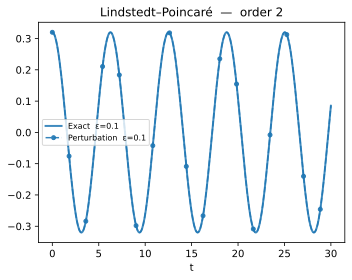

In [5]:
result = sol.compare_numeric(eps=0.1, plot_range=[0, 30], params={'A': 0.32})

---
## Example 3 — Softening spring

$$u'' + u - \varepsilon u^3 = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

Flipping the sign of the cubic term gives a **softening spring** — frequency *decreases* with amplitude.
Now $\omega_1 = -3/8$.

In [6]:
eq_soft = ODE(
    "u'' + u - eps*u**3",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"])

sol_soft = eq_soft.expand_lindstedt(order=2)
sol_soft.show()

  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

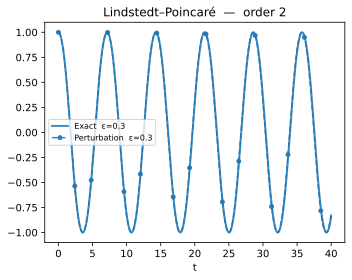

In [7]:
result = sol_soft.compare_numeric(eps=0.3, plot_range=[0, 40])

---
## Example 4 — Nonzero $\omega_0$: the 2ω oscillator

$$u'' + 4u + \varepsilon u^3 = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

Here $\omega_0 = 2$ — asymptotics detects this automatically. The strained time absorbs $\omega_0$, so in $\tau$-space the solution still has period $2\pi$.

In [8]:
eq4 = ODE(
    "u'' + 4*u + eps*u**3",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"])

sol4 = eq4.expand_lindstedt(order=2)
sol4.show()

  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Detected ω₀ = 2  (expected 2)
ω(ε) = 2


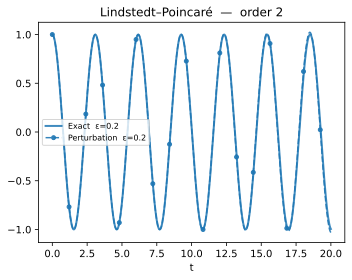

In [9]:
print(f'Detected ω₀ = {sol4.omega_0}  (expected 2)')
print(f'ω(ε) = {sol4.omega_expansion}')
result = sol4.compare_numeric(eps=0.2, plot_range=[0, 20])

---
## Example 5 — Quadratic nonlinearity

$$u'' + u + \varepsilon u^2 = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

A quadratic nonlinearity — $\omega_1 = 0$ at first order (quadratic terms don't shift the frequency at O(ε)). The frequency correction first appears at $\mathcal{O}(\varepsilon^2)$.

In [10]:
eq5 = ODE(
    "u'' + u + eps*u**2",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"])

sol5 = eq5.expand_lindstedt(order=2)
sol5.show()

  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [11]:
print('Frequency corrections:')
print(f'  ω₁ = {sol5[1].omega_k_val}  (zero — quadratic nonlinearity shifts at O(ε²))')
print(f'  ω₂ = {sol5[2].omega_k_val}')
print(f'  ω(ε) = {sol5.omega_expansion}')

Frequency corrections:
  ω₁ = 0  (zero — quadratic nonlinearity shifts at O(ε²))
  ω₂ = -5/12
  ω(ε) = 1 - 5*eps**2/12


---
## Example 6 — Higher order: order 3

Going to order 3 on the Duffing oscillator reveals the next frequency correction. With asymptotics this is now fast.

In [12]:
import time

eq = ODE(
    "u'' + u + eps*u**3",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"])

t0  = time.time()
sol = eq.expand_lindstedt(order=3)
print(f'Order 3 computed in {time.time()-t0:.2f}s')
sol.show()

  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')
Order 3 computed in 0.26s


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
## API quick reference

```python
from asymptotics import ODE

eq  = ODE("u'' + u + eps*u**3",
          dependent="u", small_param="eps", independent="t",
          conditions=["u(0) = 1", "u'(0) = 0"])

sol = eq.expand_lindstedt(order=2)

# Display
sol.show()                          # full hierarchy (LaTeX in Jupyter)

# Frequency
sol.omega_0                         # ω₀ — auto-detected
sol.omega_expansion                 # ω(ε) = ω₀ + ω₁·ε + ω₂·ε² + ...
sol[k].omega_k_val                  # ωₖ — frequency correction at order k
sol[k].secularity_condition         # Eq(secular_coeff, 0)

# Solution
sol[k].particular_solution         # uₖ(τ) — secular-free
sol.composite                       # u(τ, ε)
sol.composite_t                     # u(t, ε) with τ = ω(ε)·t substituted
sol.tau                             # the τ symbol

# Evaluate at specific ε
eps_sym   = sol.small_param
omega_val = float(sol.omega_expansion.subs(eps_sym, 0.1))
u_func    = lambdify(tau_sym, sol.composite.subs(eps_sym, 0.1), 'numpy')
u_at_t    = u_func(omega_val * t_array)   # u(t) from τ = ω·t
```

**Requirements:** `expand_lindstedt` works for 2nd-order oscillators of the form
$u'' + \omega_0^2 u + \varepsilon f(u, u') = 0$. The natural frequency $\omega_0$ is detected automatically.